In [1]:
%cd /Data/gfi/users/rogui7909/code/predict_rain_norway

/felles_gfi/felles_gfi_users/rogui7909/code/predict_rain_norway


In [2]:
print('Running imports...')
import os
import os
os.environ["MKL_THREADING_LAYER"] = "GNU"

import wandb
import numpy as np
import torch # long
import xarray as xr

from coral_pytorch.losses import corn_loss
from coral_pytorch.dataset import corn_label_from_logits
from models.model import CNN_Model, CNN_Model_ChannelAttention, CNN_Model_SpatialAttention
import pandas as pd
from torch import nn
from lightning.pytorch import loggers, seed_everything
from models.lightning import LitCNN_regression, AttributableTrainer
# from models.losses import get_loss
import matplotlib
from models.data import get_input_data_from_wandb_logger,get_input_data_from_wandb_logger_three_types
# from models.model import get_model
import matplotlib.pyplot as plt
import cmocean.cm as cmo
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
plt.style.use('robin')
# matplotlib.use('tkagg')
torch.set_float32_matmul_precision('medium')
seed_everything(42, workers=True)
import seaborn as sns 
import argparse
from tqdm.notebook import tqdm
import cartopy.crs as ccrs
import xbatcher as xb
import dask
import xbatcher
import xbatcher.loaders.torch

Running imports...


Seed set to 42


In [3]:
wandb_logger = loggers.WandbLogger(project="Predict-rain-WNorway_backtoclassif", 
                                    save_dir="/Data/gfi/users/rogui7909/wanbd_logs/",
                                    dir="/Data/gfi/users/rogui7909/wanbd_logs/wandb", )

wandb_logger.experiment # Initialize wandb

train_loader, val_loader, test_loader, ds_test = get_input_data_from_wandb_logger_three_types(wandb_logger, lon_lim=(-128, 53), add_noise=False, noise_scale=5, noisy_samples=5)

callbacks=[EarlyStopping(monitor="val/loss", mode="min")]
trainer = AttributableTrainer(limit_train_batches=100, 
                                max_epochs=wandb_logger.experiment.config['num_epochs'], 
                                logger=wandb_logger, 
                                log_every_n_steps=1, default_root_dir="/Data/gfi/users/rogui7909/lightning_checkpoint/",
                                callbacks=callbacks, deterministic=True,
                                accelerator="gpu", devices=1,)

wandb_logger.experiment.config['num_classes'] = wandb_logger.experiment.config['num_timesteps_predicted']*3
wandb_logger.experiment.config['num_channels'] = len(wandb_logger.experiment.config['input_variables'])

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: rguilcas (rguilcas-university-of-bergen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(
/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Data ready:
    Image size: 65703 (363x181)
    Input data: u850
    4 Predicted timesteps for future rainfall
    90th percentile predicted


In [4]:
class CNN_Model_test(nn.Module):
    def __init__(self, 
                 input_channels, 
                 image_size, 
                 num_timesteps,
                 number_conv_layers=7,
                 size_conv_kernel=3,
                 out_channels_conv1=12, 
                 out_channel_factor_increase_per_layer = 2,
                 ):
        super(CNN_Model_test, self).__init__()
        
        # CNN layers to extract spatial features
        # self.sigmoid = sigmoid
        # self.softmax = softmax
        self.num_timesteps = num_timesteps
        self.input_channels = input_channels
        self.classes_per_timestep = 3
        self.num_classes = self.num_timesteps*(self.classes_per_timestep-1)
        self.number_conv_layers = number_conv_layers
        max_pools = 4**6
        self.output_channels_conv1 = out_channels_conv1
        self.factor = out_channel_factor_increase_per_layer
        self.output_cnn_channels  = out_channels_conv1*out_channel_factor_increase_per_layer**(number_conv_layers-1)
        self.linear_size = 6144
        
        self.outchannel1 = self.output_channels_conv1*self.factor**0
        self.outchannel2 = self.output_channels_conv1*self.factor**1
        self.outchannel3 = self.output_channels_conv1*self.factor**2
        self.outchannel4 = self.output_channels_conv1*self.factor**3
        self.outchannel5 = self.output_channels_conv1*self.factor**4
        self.outchannel6 = self.output_channels_conv1*self.factor**5
        self.outchannel7 = self.output_channels_conv1*self.factor**6


        self.conv1 = nn.Sequential(nn.Conv2d(self.input_channels, self.outchannel1 , kernel_size=3, padding=1, stride=1),                        
                                   nn.BatchNorm2d(self.outchannel1),
                                   nn.Conv2d(self.outchannel1, self.outchannel1, kernel_size=3, padding=1, stride=2),
                                   nn.BatchNorm2d(self.outchannel1),
                                   nn.ReLU())
        self.conv2 = nn.Sequential(nn.Conv2d(self.outchannel1, self.outchannel2 , kernel_size=3, padding=1, stride=1),                        
                                   nn.BatchNorm2d(self.outchannel2),
                                   nn.Conv2d(self.outchannel2, self.outchannel2, kernel_size=3, padding=1, stride=2),
                                   nn.BatchNorm2d(self.outchannel2),
                                   nn.ReLU())
        self.conv3 = nn.Sequential(nn.Conv2d(self.outchannel2, self.outchannel3 , kernel_size=3, padding=1, stride=1),                        
                                   nn.BatchNorm2d(self.outchannel3),
                                   nn.Conv2d(self.outchannel3, self.outchannel3, kernel_size=3, padding=1, stride=2),
                                   nn.BatchNorm2d(self.outchannel3),
                                   nn.ReLU())
        self.conv4 = nn.Sequential(nn.Conv2d(self.outchannel3, self.outchannel4 , kernel_size=3, padding=1, stride=1),                        
                                   nn.BatchNorm2d(self.outchannel4),
                                   nn.Conv2d(self.outchannel4, self.outchannel4, kernel_size=3, padding=1, stride=2),
                                   nn.BatchNorm2d(self.outchannel4),
                                   nn.ReLU())
        self.conv5 = nn.Sequential(nn.Conv2d(self.outchannel4, self.outchannel5 , kernel_size=3, padding=1, stride=1),                        
                                   nn.BatchNorm2d(self.outchannel5),
                                   nn.Conv2d(self.outchannel5, self.outchannel5, kernel_size=3, padding=1, stride=2),
                                   nn.BatchNorm2d(self.outchannel5),
                                   nn.ReLU())
        self.conv6 = nn.Sequential(nn.Conv2d(self.outchannel5, self.outchannel6 , kernel_size=3, padding=1, stride=1),                        
                                   nn.BatchNorm2d(self.outchannel6),
                                   nn.Conv2d(self.outchannel6, self.outchannel6, kernel_size=3, padding=1, stride=2),
                                   nn.BatchNorm2d(self.outchannel6),
                                   nn.ReLU())
        self.conv7 = nn.Sequential(nn.Conv2d(self.outchannel6, self.outchannel7 , kernel_size=3, padding=1, stride=1),                        
                                   nn.BatchNorm2d(self.outchannel7),
                                   nn.Conv2d(self.outchannel7, self.outchannel7, kernel_size=3, padding=1, stride=2),
                                   nn.BatchNorm2d(self.outchannel7),
                                   nn.ReLU())
        
        self.fc1 = nn.Linear(self.linear_size, 512)
        self.fc2 = nn.Linear(512, self.num_classes)

    def forward(self, x):
        # x shape: (batch_size, seq_length, channels, height, width)
        # Apply CNN to extract spatial features
        batch_size,  channels, height, width = x.size()
        x1 = self.conv1(x)
        x1 = self.conv2(x1)
        x1 = self.conv3(x1)
        x1 = self.conv4(x1)
        x1 = self.conv5(x1)
        x1 = self.conv6(x1)
        x1 = self.conv7(x1)
        
        cnn_out = x1.view(batch_size, -1)  # Shape: (batch_size, seq_length, features)
        output = self.fc1(cnn_out)  # Shape: (batch_size, output_size)
        output = self.fc2(output)
        output = output.view(-1, self.num_timesteps, self.classes_per_timestep-1)
        output = torch.sigmoid(output) 
        X1 = output[:,:,0]
        X2 = output[:,:,1]
        P_norain = X1 
        P_rain = (1-X1)*(1-X2)
        P_extreme = (1-X1)*X2
        output = torch.stack([P_norain, P_rain, P_extreme], dim=2)
        return output.view(-1, self.num_timesteps*self.classes_per_timestep)
        # print(output.shape)
        
NN = CNN_Model_test(input_channels = wandb_logger.experiment.config['num_channels'], 
               image_size=wandb_logger.experiment.config['image_size'], 
               num_timesteps=wandb_logger.experiment.config['num_timesteps_predicted'],
               number_conv_layers=7,
               size_conv_kernel=wandb_logger.experiment.config['size_conv_kernel'],
               out_channels_conv1=wandb_logger.experiment.config['conv1_kernel_number'], 
               out_channel_factor_increase_per_layer = wandb_logger.experiment.config['factor_increase_kernels_per_conv_layer'],)
 
NN(train_loader.dataset[0][0])


tensor([[0.4825, 0.2588, 0.2586,  ..., 0.4646, 0.2606, 0.2748],
        [0.5353, 0.2358, 0.2289,  ..., 0.4541, 0.2812, 0.2648],
        [0.5015, 0.2709, 0.2276,  ..., 0.5023, 0.2099, 0.2877],
        ...,
        [0.4970, 0.2997, 0.2033,  ..., 0.5321, 0.2829, 0.1851],
        [0.4242, 0.2999, 0.2758,  ..., 0.5479, 0.2455, 0.2066],
        [0.5379, 0.2429, 0.2192,  ..., 0.5239, 0.2412, 0.2349]],
       grad_fn=<ViewBackward0>)

In [15]:
NN = CNN_Model_test(input_channels = wandb_logger.experiment.config['num_channels'], 
               image_size=wandb_logger.experiment.config['image_size'], 
               num_timesteps=wandb_logger.experiment.config['num_timesteps_predicted'],
               number_conv_layers=7,
               size_conv_kernel=wandb_logger.experiment.config['size_conv_kernel'],
               out_channels_conv1=wandb_logger.experiment.config['conv1_kernel_number'], 
               out_channel_factor_increase_per_layer = wandb_logger.experiment.config['factor_increase_kernels_per_conv_layer'],)
 

class MultiCrossEntropyLoss(nn.Module):
    def __init__(self, timesteps):
        super(MultiCrossEntropyLoss, self).__init__()
        self.nll = torch.nn.NLLLoss(weight = torch.Tensor([1,1,9]))
        self.timesteps = timesteps
        
    def forward(self, pred, target):
        """
        Computes the loss for the given prediction.
        """
        loss = []
        pred = pred.view(-1, self.timesteps, 3)
        proba = torch.softmax(pred, dim=2)
        for k,timestep in enumerate(range(self.timesteps)):
            res = self.nll(torch.log(proba[:,timestep]), target[:,timestep])
            loss.append(res)#*(k+1)/10)
        loss = torch.mean(torch.stack(loss))
        return loss
    

loss = MultiCrossEntropyLoss(timesteps = wandb_logger.experiment.config['num_timesteps_predicted'])


model = LitCNN_regression(NN, 
                          learning_rate=wandb_logger.experiment.config['learning_rate'], 
                          lr_scheduler =wandb_logger.experiment.config['lr_scheduler'],
                          loss_fn = loss)

trainer.fit(model, train_loader, val_loader)


RuntimeError: [enforce fail at alloc_cpu.cpp:119] err == 0. DefaultCPUAllocator: can't allocate memory: you tried to allocate 551905394688 bytes. Error code 12 (Cannot allocate memory)

In [6]:
model.eval()
with torch.no_grad():
    trainer.test(model, dataloaders=val_loader)
wandb.finish()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │    0.9360523223876953     │
└───────────────────────────┴───────────────────────────┘

epoch,▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▅▅▆▆▆▆▆▆▆▇▇▇▇████████
test/loss,▁
train/loss,███▇▇▆▆▆▅▅▄▅▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▂▁▁▁▁▁
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇█
val/loss,█▃▂▁▁▁▂▂
epoch,8
test/loss,0.93605
train/loss,0.73296
trainer/global_step,288
val/loss,0.93605


[Text(0, 0, 'D0'), Text(1, 0, 'D+1'), Text(2, 0, 'D+2'), Text(3, 0, 'D+3')]

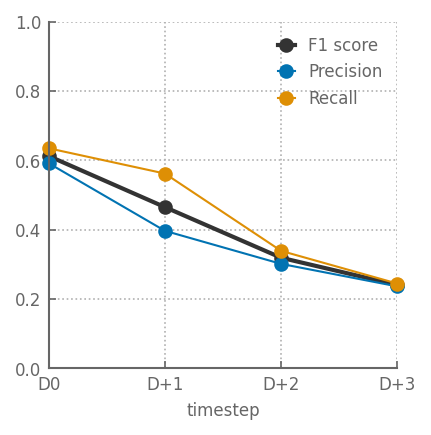

In [7]:
y_test = torch.stack(model.test_true_values)#.cpu().numpy()
y_scores = torch.stack(model.test_pred).view(-1, wandb_logger.experiment.config['num_timesteps_predicted'], 3).cpu()
preds = torch.argmax(y_scores, dim=2)
targets=xr.DataArray(y_test.cpu().numpy(), dims=['time','timestep'], coords=dict(time=ds_test.time[:y_test.shape[0]], timestep=np.arange(y_scores.shape[1])))
preds=xr.DataArray(preds.cpu().numpy(), dims=['time','timestep'], coords=dict(time=ds_test.time[:y_test.shape[0]], timestep=np.arange(y_scores.shape[1])))
results = xr.Dataset(dict(targets=targets, preds=preds))
df_=pd.DataFrame(dict(pred=preds.to_series(), targets=targets.to_series()))
df_['pred_time'] = (df_.index.get_level_values(0)+pd.Timedelta(1,'D')*df_.index.get_level_values(1)).values

TP = ((preds == targets)&(targets==2)).sum('time')
recall = TP / (targets==2).sum('time')
precision = TP / (preds==2).sum('time')
f1 = 2*(precision*recall)/(precision+recall)



# recall_season.plot(hue='season')
fig, ax = plt.subplots(figsize=(3,3,))
f1.plot(color='.2', lw=2, label='F1 score', marker='o', clip_on=False)
precision.plot(label='Precision', marker='o', clip_on=False)
recall.plot(label='Recall', marker='o', clip_on=False)
plt.legend()
ax.set_ylim(0,1)
ax.grid()
ax.set_xlim(0,3)
ax.set_xticks([0,1,2,3])
ax.set_xticklabels(['D0','D+1','D+2','D+3'])

In [8]:
%%time

df_=pd.DataFrame(dict(pred=preds.to_series(), targets=targets.to_series()))
df_['pred_time'] = (df_.index.get_level_values(0)+pd.Timedelta(1,'D')*df_.index.get_level_values(1)).values

times = df_.query("targets==2 & pred==2").groupby('pred_time').count().pred.sort_values()
events_predicted = times.loc[times>3].index
steps = 4
start_times = events_predicted -  pd.Timedelta(steps-1,'D')
print("Number of 4x events:",len(start_times))
num_extremes = df_.targets.loc[df_.targets==2].unstack().count(axis=1)
num_extremes_pred = df_.targets.where((df_.targets==2)&(df_.pred==2)).fillna(0).unstack().sum(axis=1)//2

pred_FP = df_.query("pred==2 & targets<2").groupby('pred_time').count().query("pred==4").index

start_times_FP = pred_FP - pd.Timedelta(steps-1,'D')
# events

steps = 4

from captum.attr import IntegratedGradients
method = IntegratedGradients(model.model)
all_multi_attrs = []
all_multi_sens = []

for k in tqdm(range(len(events_predicted))):
    start = start_times[k].strftime("%Y-%m-%d %H:%M:%S")
    end = events_predicted[k].strftime("%Y-%m-%d %H:%M:%S")
    # print(start,end)
    ds_test_extract = ds_test.sel(time=slice(start ,end))
    tensor_in = torch.Tensor(ds_test_extract.inputs.values)
    tensor_out = torch.Tensor(ds_test_extract.targets.values)
    attrs = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[3*(steps-k)-1 for k in range(steps)]) 
    da_attrs = xr.DataArray(attrs, dims = ['timestep','var_name','latitude','longitude'], 
                            coords= dict(timestep=np.arange(1,steps+1),var_name=ds_test_extract.var_name, latitude=ds_test_extract.latitude, longitude=ds_test_extract.longitude))
    all_multi_attrs.append(da_attrs.assign_coords(time=events_predicted[k]))
    sens = da_attrs/ds_test_extract.inputs.rename(time='timestep').assign_coords(timestep=da_attrs.timestep)
    all_multi_sens.append(sens.assign_coords(time=events_predicted[k]))
ds_attributions = xr.concat(all_multi_attrs, dim='time')
ds_sens = xr.concat(all_multi_sens, dim='time')

Number of 4x events: 21


  0%|          | 0/21 [00:00<?, ?it/s]

CPU times: user 11min 48s, sys: 1min 37s, total: 13min 26s
Wall time: 1min


In [9]:
final_ds = xr.Dataset(dict(attributions = ds_attributions, sensitivity=ds_sens))
final_ds = final_ds.rename(time='attribution_time')
final_ds = xr.merge([final_ds, results.assign_coords(timestep=np.arange(1,5))])
n = wandb_logger.experiment.config['num_conv_layer']
# final_ds.to_netcdf(f'out_data/rosendal/highres_cnn7_newlinus_attributions.nc')

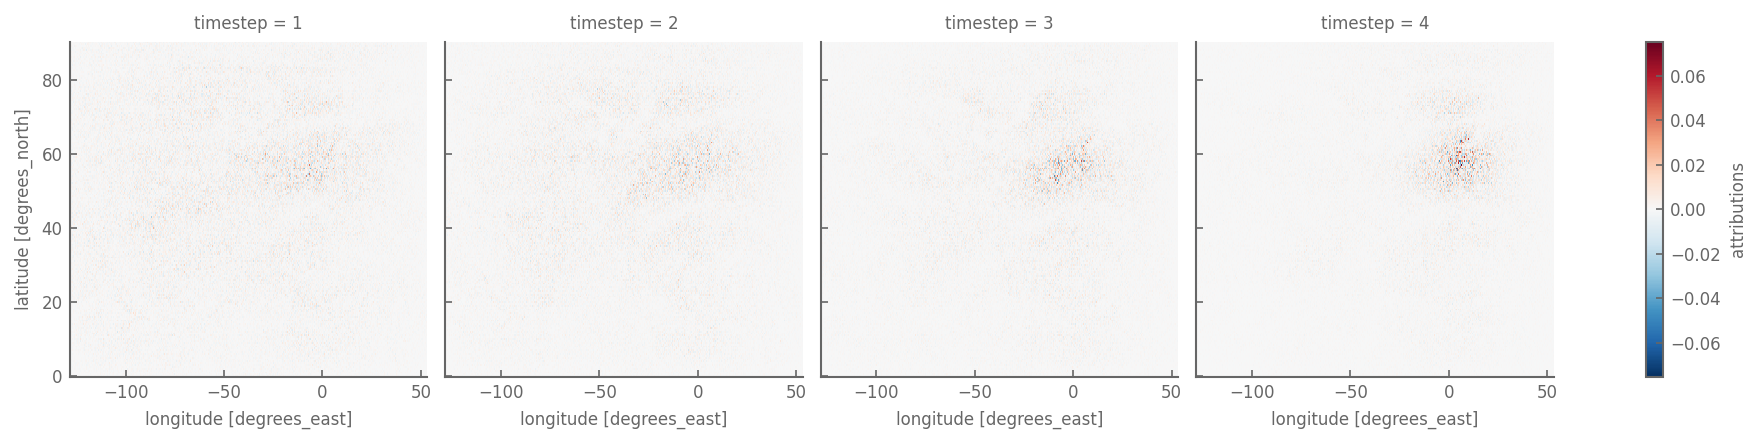

In [13]:
final_ds.mean('attribution_time').attributions.plot(col='timestep')